### Linear regression assumption

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_csv("../data/data.csv")
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [50]:
X = df.iloc[:, 0:3]
y = df.iloc[:, -1]

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,
                                                     test_size=0.2,
                                                     random_state=2)

In [52]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[74.37, 0.26,53.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['feature1','feature2','feature3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4319
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [53]:
y_pred = model.predict(X_test)
y_pred

array([  10.64254095,   -7.67571336,  -48.65162017,  -41.47101521,
        -32.19434723, -145.14932998,  -69.09035887,   48.95410029,
        129.27537865,  172.80029457,  -80.11833775,  187.21165476,
        186.70001539, -181.33673699,   12.27542574,   45.89208668,
         69.42140749,   23.26801325, -240.7043195 ,  -66.59427421,
        -62.32848291,   21.08341372, -106.45658202,   -6.50701124,
        -10.81672854,   53.85943172,  -31.19156878,   79.81741035,
        -54.3228099 ,  -73.92445664,  142.85275381,  136.67009397,
         14.28926543,  -33.75029881,   99.9413708 ,  170.72866042,
         58.73580228,   29.73302765,   61.00023174,   24.26491242])

In [54]:
# Residual
residual = y_test - y_pred

#### Assumptions

**1. Linear Relationship**

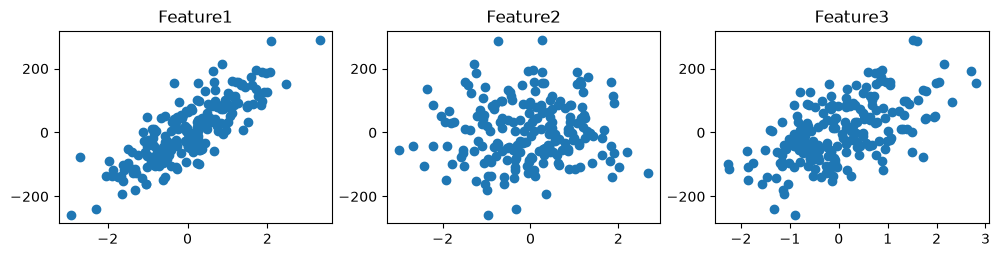

In [55]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

**2. Multicollinearity**

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = []
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [57]:
pd.DataFrame({
    "vif" : vif
}, index =df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.003489,1.0052,1.006431


<Axes: >

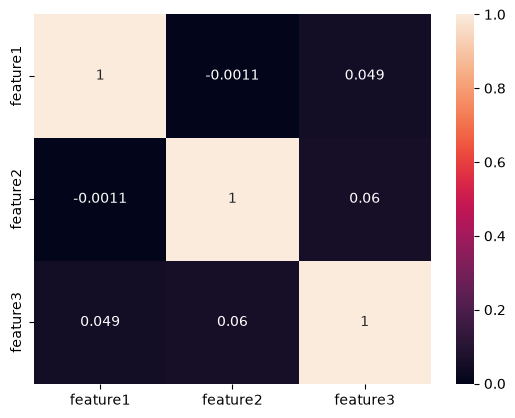

In [58]:
# Another way
sns.heatmap(df.iloc[:,0:3].corr(), annot=True)

**3. Normal Residual**

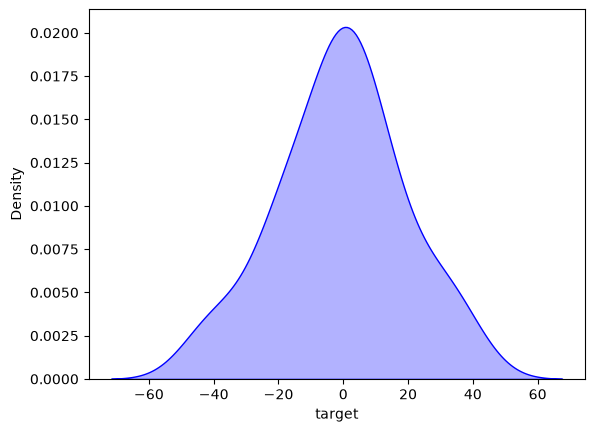

In [59]:
sns.kdeplot(residual,fill=True, color="blue", alpha=0.3);

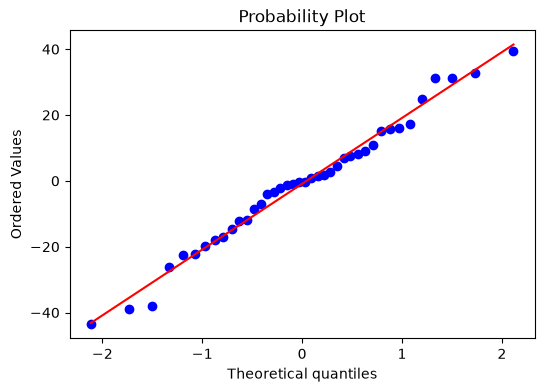

In [60]:
## QQ plot
import scipy as sp
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)
plt.show()

**4. Homoscedasticity**

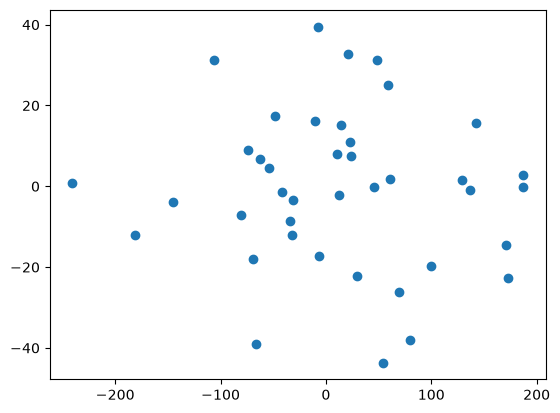

In [61]:
plt.scatter(y_pred,residual);

**5. Autocorrelation of Residuals**

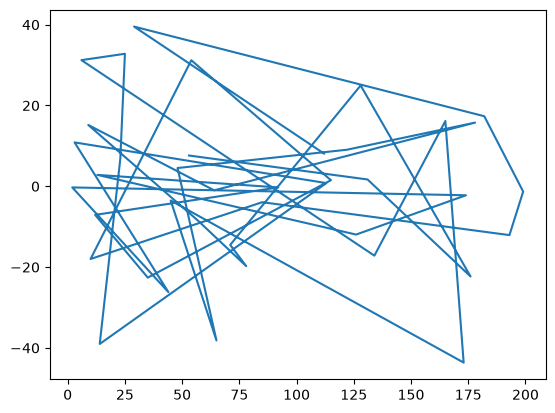

In [62]:
plt.plot(residual);